# Prior elicitation for free AMPK signaling parameters

Nathaniel Linden-Santangeli, Oct 2024

In [17]:
import pandas as pd
import numpy as np
import preliz as pz
import json
import matplotlib.pyplot as plt

We want to choose priors such that a specified proportion of the the probability mass lies between the upper and lower bounds. 

To do so, we wil use the `Preliz` python package for prior elicitation and explore a few different options for the prior, including:
- lognormal, and
- gamma

In [18]:
# Get the upper lower bounds for the free parameters
# MA info
with open('../odes/MA_single.json', 'r') as file:
           MA_info = json.load(file)

MA_free_params = ["kOffAMP","kOffADP","kOffATP","kOffCaMKK","kPhosCaMKK","kOffLKB1","kPhosLKB1","kOffPP","kDephosPP","kOffAMPK","kPhosAMPK","kOffPP1","kDephosPP1"]

# MM info
with open('../odes/MM_single.json', 'r') as file:
           MM_info = json.load(file)

MM_free_params = ["kOffAMP","kOffADP","kOffATP","kPhosCaMKK","KmCaMKK","kPhosLKB1","KmLKB1","kDephosPP","KmPP"]

# SET BOUNDS HERE
lower_bound_mult = 0.1
upper_bound_mult = 10
bounds_mult = np.array([lower_bound_mult, upper_bound_mult])
MA_bounds = {param: bounds_mult * MA_info['nominal_params'][param] for param in MA_free_params}
MM_bounds = {param: bounds_mult * MM_info['nominal_params'][param] for param in MM_free_params}

### Explore different prior families and the effects of different proportions of the probability mass between the upper and lower bounds

MA kOffAMP bounds:  [0.00025 0.025  ]


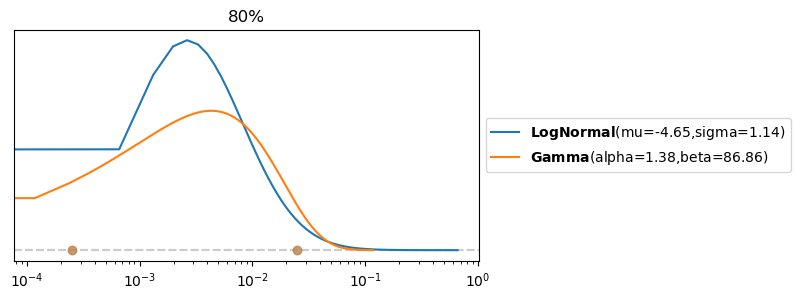

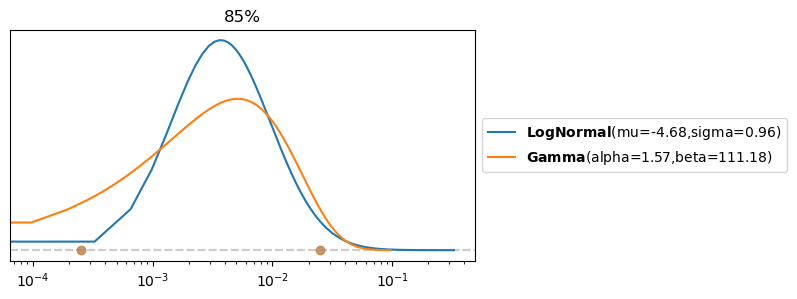

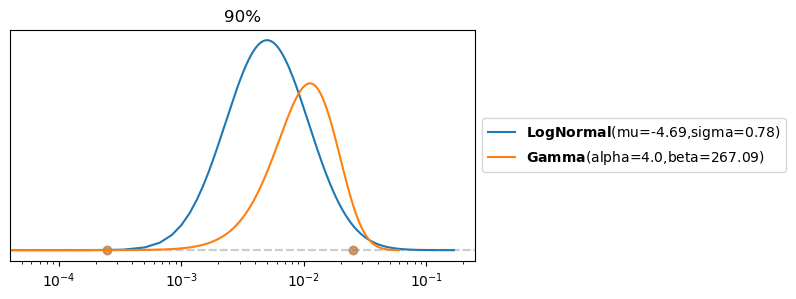

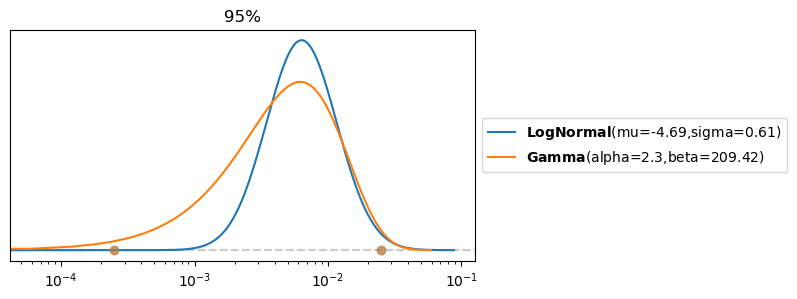

In [28]:
# Use MA param: kOffAMP as an example
print("MA kOffAMP bounds: ", MA_bounds["kOffAMP"])

# 80%
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
pz.maxent(pz.LogNormal(), MA_bounds["kOffAMP"][0], MA_bounds["kOffAMP"][1], 0.8, ax = ax)
pz.maxent(pz.Gamma(), MA_bounds["kOffAMP"][0], MA_bounds["kOffAMP"][1], 0.8, ax = ax)
ax.set_title("80%")
ax.set_xscale('log')

# 85%
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
pz.maxent(pz.LogNormal(), MA_bounds["kOffAMP"][0], MA_bounds["kOffAMP"][1], 0.85, ax = ax)
pz.maxent(pz.Gamma(), MA_bounds["kOffAMP"][0], MA_bounds["kOffAMP"][1], 0.85, ax = ax)
ax.set_title("85%")
ax.set_xscale('log')

# 90%
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
pz.maxent(pz.LogNormal(), MA_bounds["kOffAMP"][0], MA_bounds["kOffAMP"][1], 0.9, ax = ax)
pz.maxent(pz.Gamma(), MA_bounds["kOffAMP"][0], MA_bounds["kOffAMP"][1], 0.9, ax = ax)
ax.set_title("90%")
ax.set_xscale('log')

# 95%
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
pz.maxent(pz.LogNormal(), MA_bounds["kOffAMP"][0], MA_bounds["kOffAMP"][1], 0.95, ax = ax)
pz.maxent(pz.Gamma(), MA_bounds["kOffAMP"][0], MA_bounds["kOffAMP"][1], 0.95, ax = ax)
ax.set_title("95%")
ax.set_xscale('log')

The $95\%$ case with the Gamma density or the $85\%$ and $90\%$ cases with the lognormal density are the most reasonable choices.

Lets try this again with a different parameter.

MM KmAMPK bounds:  [ 0.14 14.  ]


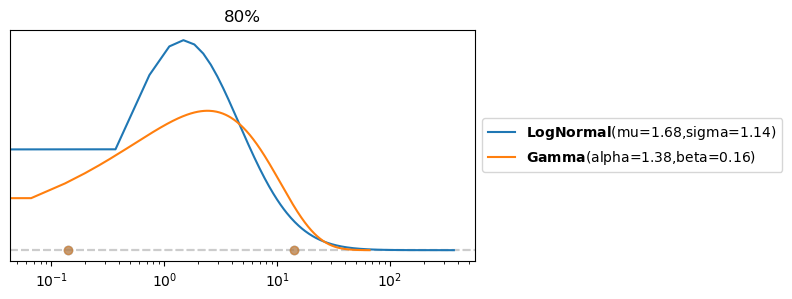

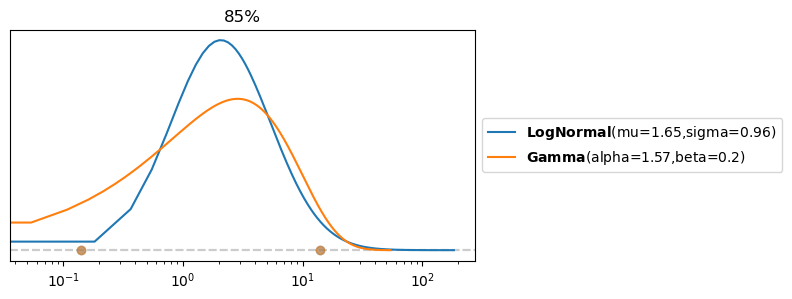

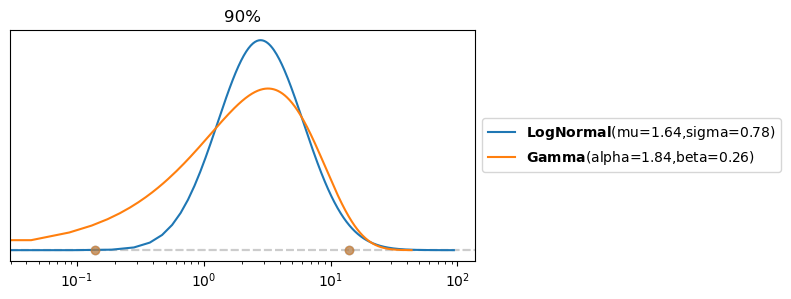

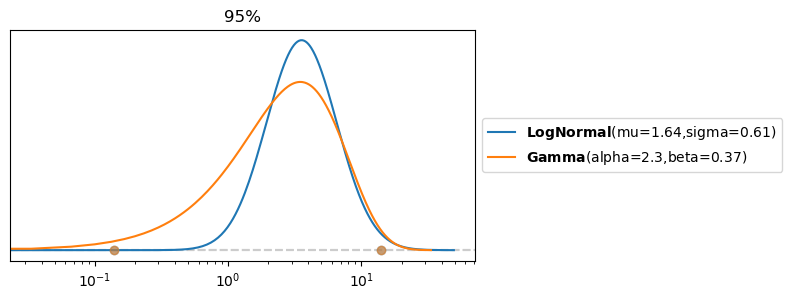

In [30]:
# Use MA param: kOffAMP as an example
print("MM KmAMPK bounds: ", MM_bounds["KmLKB1"])

# 80%
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
pz.maxent(pz.LogNormal(), MM_bounds["KmLKB1"][0], MM_bounds["KmLKB1"][1], 0.8, ax = ax)
pz.maxent(pz.Gamma(), MM_bounds["KmLKB1"][0], MM_bounds["KmLKB1"][1], 0.8, ax = ax)
ax.set_title("80%")
ax.set_xscale('log')

# 85%
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
pz.maxent(pz.LogNormal(), MM_bounds["KmLKB1"][0], MM_bounds["KmLKB1"][1], 0.85, ax = ax)
pz.maxent(pz.Gamma(), MM_bounds["KmLKB1"][0], MM_bounds["KmLKB1"][1], 0.85, ax = ax)
ax.set_title("85%")
ax.set_xscale('log')

# 90%
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
pz.maxent(pz.LogNormal(), MM_bounds["KmLKB1"][0], MM_bounds["KmLKB1"][1], 0.9, ax = ax)
pz.maxent(pz.Gamma(), MM_bounds["KmLKB1"][0], MM_bounds["KmLKB1"][1], 0.9, ax = ax)
ax.set_title("90%")
ax.set_xscale('log')

# 95%
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
pz.maxent(pz.LogNormal(), MM_bounds["KmLKB1"][0], MM_bounds["KmLKB1"][1], 0.95, ax = ax)
pz.maxent(pz.Gamma(), MM_bounds["KmLKB1"][0], MM_bounds["KmLKB1"][1], 0.95, ax = ax)
ax.set_title("95%")
ax.set_xscale('log')

Very similar results this time, lets use the Gamma $95\%$ case. 

In [48]:
# GAMMA DISTRIBUTION
mass = 0.95

# MA single
MA_params = {}
for param in MA_free_params:
    result = pz.maxent(pz.Gamma(), MA_bounds[param][0], MA_bounds[param][1], mass, plot=False)[1]['x']
    MA_params[param] = {'alpha': round(result[0], 3), 'beta': round(result[1], 3)}

# save
with open('../odes/MA_single_gamma.json', 'w') as file:
    json.dump(MA_params, file)

# MM single
MM_params = {}
for param in MM_free_params:
    result = pz.maxent(pz.Gamma(), MM_bounds[param][0], MM_bounds[param][1], mass, plot=False)[1]['x']
    MM_params[param] = {'alpha': round(result[0], 3), 'beta': round(result[1], 3)}

# save
with open('../odes/MM_single_gamma.json', 'w') as file:
    json.dump(MM_params, file)